<a href="https://colab.research.google.com/github/suchithgali/pytorch_practice/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn #contains all of pytorch's building blocks for neural networks
import matplotlib.pyplot as plt

torch.__version__

'2.9.0+cpu'

In [40]:
#creating parameters
weight = 0.7
bias = 0.3

# data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [41]:
len(X), len(y)

(50, 50)

In [42]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [43]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions=None):

  """
  Plot training data, test data and compares predictions.
  """

  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size": 14});

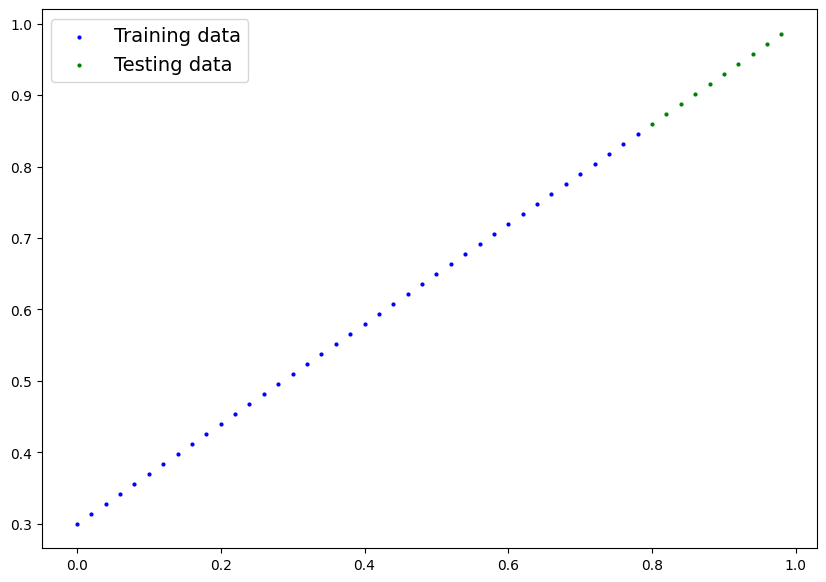

In [44]:
plot_predictions();

In [45]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1, requires_grad= True, dtype = torch.float)) #start with random values of size 1
    self.bias = nn.Parameter(torch.rand(1, requires_grad= True, dtype = torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias #linear regression

In [90]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [91]:
#when making predictions use inference mode, inference mode doesn't save gradients
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [92]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

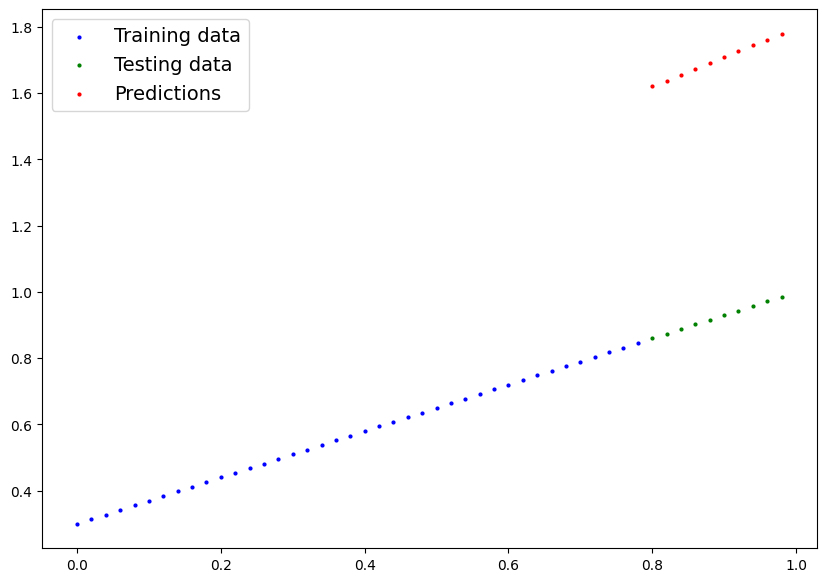

In [93]:
plot_predictions(predictions = y_preds)

In [94]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [95]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [96]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)

In [97]:
epochs = 200 #one loop through the data

#tracking different values
epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
  model_0.train() #set model to training mode, sets all parameters that require gradients to require gradients

  y_pred = model_0(X_train) #do forward propogation

  loss = loss_fn(y_pred, y_train) #calculate the loss

  optimizer.zero_grad() #optimizer zero grad

  loss.backward() #perform backpropogation

  optimizer.step() #perform gradient descent, the optimizer changes will accumulate so need to 0 them above for each loop

  # Evaluation and printing moved inside the loop to show progress
  model_0.eval() # turn off settings not needed for evaluation for inference
  with torch.inference_mode(): # turns off gradient tracking for inference
    test_pred = model_0(X_test) # do forward pass on test data
    test_loss = loss_fn(test_pred, y_test) # calculate loss on test data

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

# After the loop, the model remains in eval mode from the last iteration.
# If further training steps were to occur, it would be switched back to train mode.

Epoch: 0 | Train Loss: 0.6861 | Test Loss: 0.7638
Epoch: 10 | Train Loss: 0.5709 | Test Loss: 0.6290
Epoch: 20 | Train Loss: 0.4557 | Test Loss: 0.4943
Epoch: 30 | Train Loss: 0.3405 | Test Loss: 0.3596
Epoch: 40 | Train Loss: 0.2252 | Test Loss: 0.2249
Epoch: 50 | Train Loss: 0.1100 | Test Loss: 0.0902
Epoch: 60 | Train Loss: 0.0097 | Test Loss: 0.0210
Epoch: 70 | Train Loss: 0.0062 | Test Loss: 0.0141
Epoch: 80 | Train Loss: 0.0028 | Test Loss: 0.0058
Epoch: 90 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 100 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 110 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 120 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 130 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 140 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 150 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 160 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 170 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 180 | Train Loss: 0.0071 | Test Loss: 0.0075
Epoch: 190 | Train Loss

In [98]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [99]:
with torch.inference_mode():
  y_pred_new = model_0(X_test)


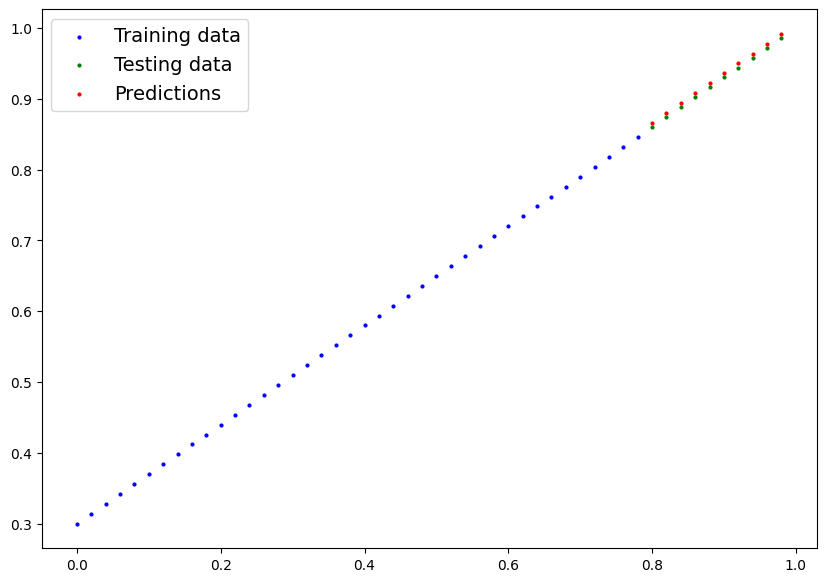

In [100]:
  plot_predictions(predictions=y_pred_new)

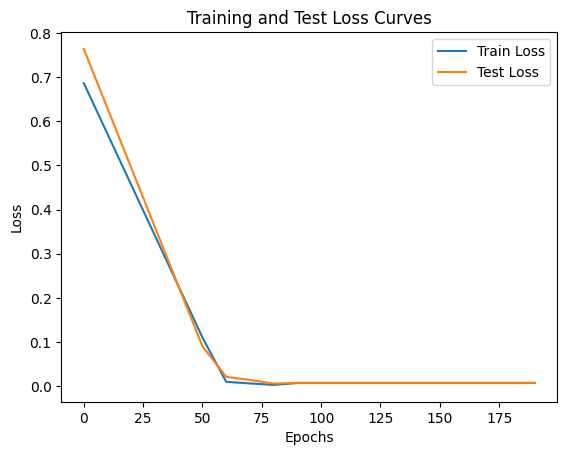

In [105]:
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label = 'Train Loss')
plt.plot(epoch_count, test_loss_values, label = 'Test Loss')
plt.title('Training and Test Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();